In [1]:
import pandas as pd
from IPython.core.pylabtools import figsize
from IPython.utils.dir2 import safe_hasattr

(a) To begin, load in the Boston data set, which is part of the ISLP
library.

In [2]:
boston = pd.read_csv('../data/Boston.csv')
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


(b) How many rows are in this data set? How many columns? What do the rows and columns represent?

In [3]:
dimensions = boston.shape
print(f'rows: {dimensions[0]}, columns: {dimensions[1]}')

rows: 506, columns: 13


In [4]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


(c) Make some pairwise scatterplots of the predictors (columns) in this data set. Describe your findings.

array([[<Axes: xlabel='crim', ylabel='crim'>,
        <Axes: xlabel='zn', ylabel='crim'>,
        <Axes: xlabel='indus', ylabel='crim'>,
        <Axes: xlabel='chas', ylabel='crim'>,
        <Axes: xlabel='nox', ylabel='crim'>,
        <Axes: xlabel='rm', ylabel='crim'>,
        <Axes: xlabel='age', ylabel='crim'>,
        <Axes: xlabel='dis', ylabel='crim'>,
        <Axes: xlabel='rad', ylabel='crim'>,
        <Axes: xlabel='tax', ylabel='crim'>,
        <Axes: xlabel='ptratio', ylabel='crim'>,
        <Axes: xlabel='lstat', ylabel='crim'>,
        <Axes: xlabel='medv', ylabel='crim'>],
       [<Axes: xlabel='crim', ylabel='zn'>,
        <Axes: xlabel='zn', ylabel='zn'>,
        <Axes: xlabel='indus', ylabel='zn'>,
        <Axes: xlabel='chas', ylabel='zn'>,
        <Axes: xlabel='nox', ylabel='zn'>,
        <Axes: xlabel='rm', ylabel='zn'>,
        <Axes: xlabel='age', ylabel='zn'>,
        <Axes: xlabel='dis', ylabel='zn'>,
        <Axes: xlabel='rad', ylabel='zn'>,
        <Axes: x

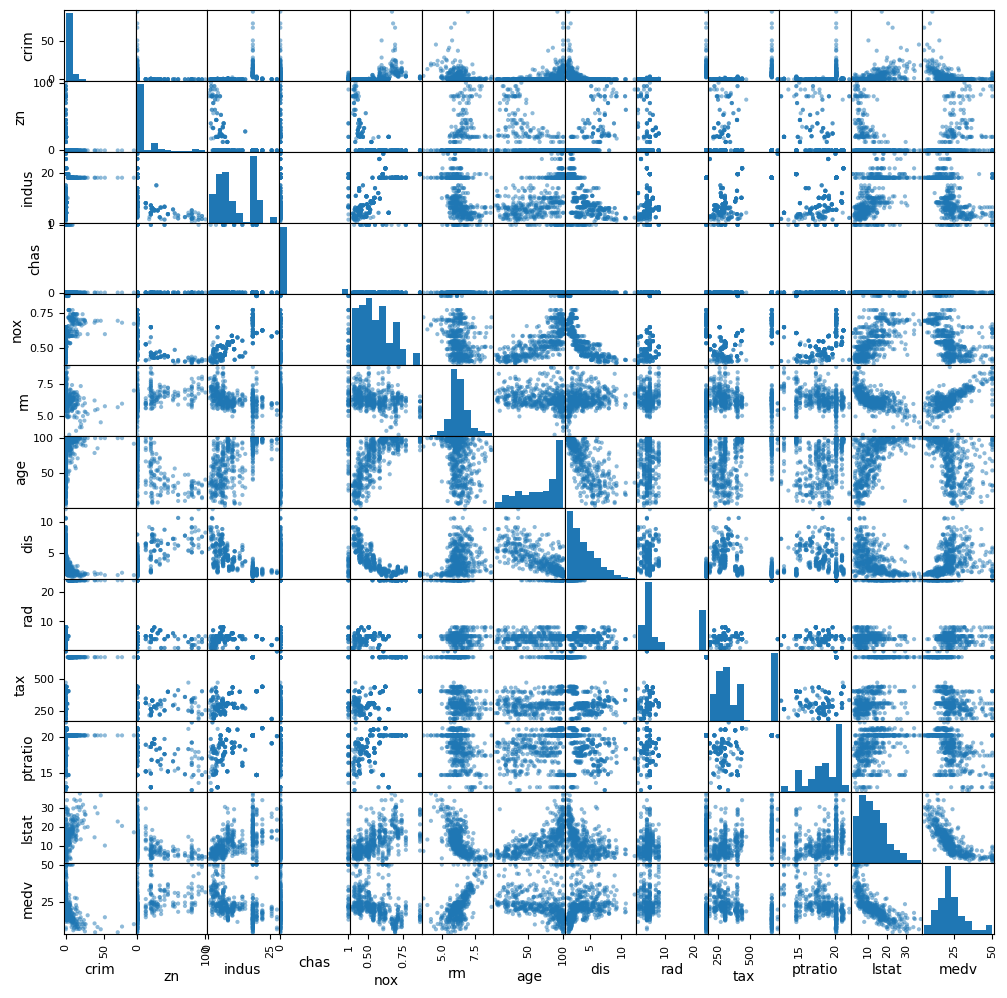

In [5]:
pd.plotting.scatter_matrix(boston, figsize=(12,12))

(d) Are any of the predictors associated with per capita crime rate? If so, explain the relationship

<Axes: xlabel='nox', ylabel='crim'>

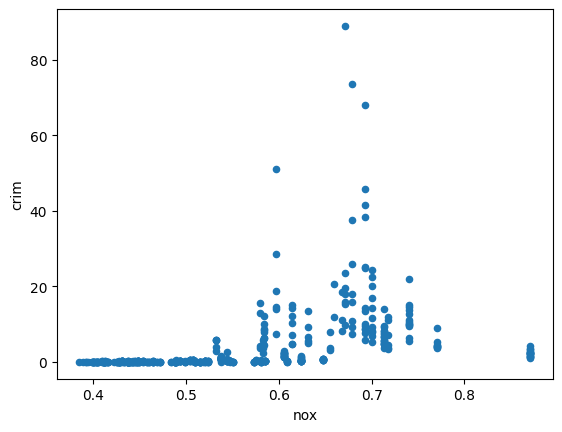

In [6]:
boston.plot.scatter(x='nox',y='crim')

<Axes: xlabel='dis', ylabel='crim'>

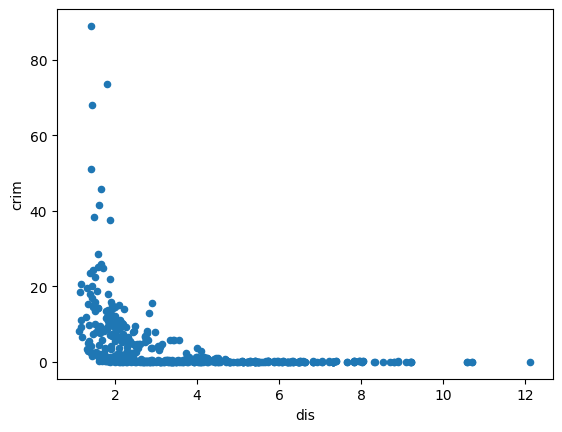

In [7]:
boston.plot.scatter(x='dis',y='crim')

<Axes: xlabel='medv', ylabel='crim'>

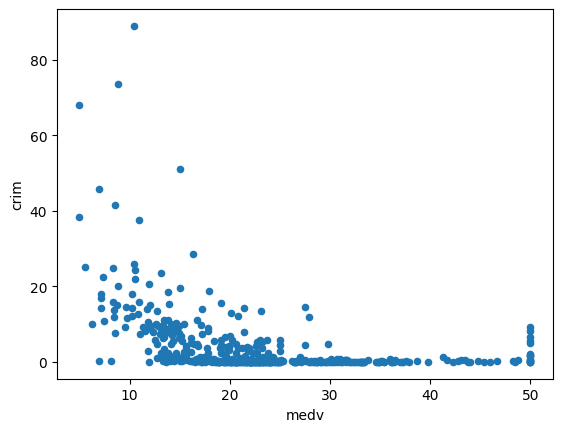

In [8]:
boston.plot.scatter(x='medv',y='crim')

Do any of the suburbs of Boston appear to have particularly high crime rates? Tax rates? Pupil-teacher ratios? Comment on the range of each predictor.

In [9]:
print(f'max_crime_rate = {boston['crim'].max()}, min_crime_rate = {boston['crim'].min()}')
print(f'max_tax_rate = {boston['tax'].max()}, min_tax_rate = {boston['tax'].min()}')
print(f'max_ptratio = {boston['ptratio'].max()}, min_ptratio = {boston['ptratio'].min()}')

max_crime_rate = 88.9762, min_crime_rate = 0.00632
max_tax_rate = 711, min_tax_rate = 187
max_ptratio = 22.0, min_ptratio = 12.6


(f) How many of the suburbs in this data set bound the Charles river?

In [10]:
boston.loc[boston['chas'] == 1, ].count().max()

np.int64(35)

(g) What is the median pupil-teacher ratio among the towns in this data set?

In [11]:
boston[['ptratio']].median()

ptratio    19.05
dtype: float64

In [12]:
boston['ptratio'].median()

np.float64(19.05)

(h) Which suburb of Boston has lowest median value of owner- occupied homes? What are the values of the other predictors for that suburb, and how do those values compare to the overall ranges for those predictors?

In [13]:
min_median_medv = boston[boston['medv'] == boston['medv'].min()]
min_median_medv = min_median_medv.T
min_median_medv.columns = ['min_1', 'min_2']
min_median_medv

,min_1,min_2
crim,38.3518,67.9208
zn,0.0000,0.0000
indus,18.1000,18.1000
chas,0.0000,0.0000
nox,0.6930,0.6930
rm,5.4530,5.6830
age,100.0000,100.0000
dis,1.4896,1.4254
rad,24.0000,24.0000
tax,666.0000,666.0000


In [14]:
boston_mean = boston[:].mean()
boston_median = boston[:].median()
boston_med = pd.concat([boston_mean, boston_median], axis=1, keys=['boston-mean', 'boston-median'])
boston_med

,boston-mean,boston-median
crim,3.613524,0.25651
zn,11.363636,0.00000
indus,11.136779,9.69000
chas,0.069170,0.00000
nox,0.554695,0.53800
rm,6.284634,6.20850
age,68.574901,77.50000
dis,3.795043,3.20745
rad,9.549407,5.00000
tax,408.237154,330.00000


In [15]:
boston_min_comparative = pd.concat([boston_med, min_median_medv], axis=1)
boston_min_comparative

,boston-mean,boston-median,min_1,min_2
crim,3.613524,0.25651,38.3518,67.9208
zn,11.363636,0.00000,0.0000,0.0000
indus,11.136779,9.69000,18.1000,18.1000
chas,0.069170,0.00000,0.0000,0.0000
nox,0.554695,0.53800,0.6930,0.6930
rm,6.284634,6.20850,5.4530,5.6830
age,68.574901,77.50000,100.0000,100.0000
dis,3.795043,3.20745,1.4896,1.4254
rad,9.549407,5.00000,24.0000,24.0000
tax,408.237154,330.00000,666.0000,666.0000


(i) In this data set, how many of the suburbs average more than seven rooms per dwelling? More than eight rooms per dwelling? Comment on the suburbs that average more than eight rooms per dwelling.

In [17]:
boston[boston['rm'] > 7].count().min()

np.int64(64)

In [27]:
boston_rm_8 = boston[boston['rm'] > 8]
boston_rm_8.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.718795,13.615385,7.078462,0.153846,0.539238,8.348538,71.538462,3.430192,7.461538,325.076923,16.361538,4.310000,44.200000
std,0.901640,26.298094,5.392767,0.375534,0.092352,0.251261,24.608723,1.883955,5.332532,110.971063,2.410580,1.373566,8.092383
min,0.020090,0.000000,2.680000,0.000000,0.416100,8.034000,8.400000,1.801000,2.000000,224.000000,13.000000,2.470000,21.900000
25%,0.331470,0.000000,3.970000,0.000000,0.504000,8.247000,70.400000,2.288500,5.000000,264.000000,14.700000,3.320000,41.700000
50%,0.520140,0.000000,6.200000,0.000000,0.507000,8.297000,78.300000,2.894400,7.000000,307.000000,17.400000,4.140000,48.300000
75%,0.578340,20.000000,6.200000,0.000000,0.605000,8.398000,86.500000,3.651900,8.000000,307.000000,17.400000,5.120000,50.000000
max,3.474280,95.000000,19.580000,1.000000,0.718000,8.780000,93.900000,8.906700,24.000000,666.000000,20.200000,7.440000,50.000000


In [30]:
boston_rm_8.mean()

crim         0.718795
zn          13.615385
indus        7.078462
chas         0.153846
nox          0.539238
rm           8.348538
age         71.538462
dis          3.430192
rad          7.461538
tax        325.076923
ptratio     16.361538
lstat        4.310000
medv        44.200000
dtype: float64

In [31]:
boston[boston['rm'] <= 8].mean()

crim         3.689855
zn          11.304260
indus       11.243793
chas         0.066937
nox          0.555103
rm           6.230211
age         68.496755
dis          3.804663
rad          9.604462
tax        410.430020
ptratio     18.510751
lstat       12.873063
medv        21.961460
dtype: float64

In [32]:
boston_rm_8.median()

crim         0.52014
zn           0.00000
indus        6.20000
chas         0.00000
nox          0.50700
rm           8.29700
age         78.30000
dis          2.89440
rad          7.00000
tax        307.00000
ptratio     17.40000
lstat        4.14000
medv        48.30000
dtype: float64

In [33]:
boston[boston['rm'] <= 8].median()

crim         0.24522
zn           0.00000
indus        9.69000
chas         0.00000
nox          0.53800
rm           6.18500
age         77.30000
dis          3.21570
rad          5.00000
tax        334.00000
ptratio     19.10000
lstat       11.65000
medv        21.00000
dtype: float64